# 01 - Baseline CNN Training

Trains the **Baseline CNN** on the original (un-augmented) dataset.

**Split strategy:** The labelled `train.csv` is split 80/20 (train/val). The Kaggle `test/` folder is unlabelled — Section 7 generates the submission file for the leaderboard.

## 1. Setup & Imports

In [1]:
import os, sys, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

from sklearn.metrics import accuracy_score, f1_score, classification_report
import kagglehub

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

if torch.cuda.is_available():            device = torch.device('cuda')
elif torch.backends.mps.is_available(): device = torch.device('mps')
else:                                    device = torch.device('cpu')
print('Device:', device)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
for c in [os.path.join(NOTEBOOK_DIR,'../src'), os.path.join(NOTEBOOK_DIR,'src'),
          '/Applications/Universidade/4ano_2semestre/ACA/projeto2/aml-butterfly-generative-augmentation/src']:
    c = os.path.abspath(c)
    if os.path.isdir(c) and c not in sys.path:
        sys.path.append(c); break

from dataset import ButterflyDataset
from transforms import get_transforms
from models import BaselineCNN
from utils import get_splits, get_class_mapping, GLOBAL_SEED
print('Modules imported!')

/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps
Modules imported!


## 2. Load Dataset & Create 80/20 Split

In [2]:
path = kagglehub.competition_download('aca-tp-2')
train_dir = os.path.join(path, 'train')
test_dir  = os.path.join(path, 'test')   # unlabelled

df = pd.read_csv(os.path.join(path, 'train.csv'))[['filename', 'label']]

train_df, val_df = get_splits(df, seed=GLOBAL_SEED)
class_to_idx, idx_to_class, classes = get_class_mapping(df)
NUM_CLASSES = len(classes)

total = len(df)
print(f'Total      : {total}')
print(f'Train      : {len(train_df)}  ({len(train_df)/total*100:.1f}%)')
print(f'Validation : {len(val_df)}   ({len(val_df)/total*100:.1f}%)')
print(f'Classes    : {NUM_CLASSES}')

Total      : 5199
Train      : 4159  (80.0%)
Validation : 1040   (20.0%)
Classes    : 75


## 3. DataLoaders

In [3]:
BATCH_SIZE = 32
train_transform, val_transform = get_transforms()

train_dataset = ButterflyDataset(df=train_df, img_dir=train_dir, transform=train_transform)
val_dataset   = ButterflyDataset(df=val_df,   img_dir=train_dir, transform=val_transform)

train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = data.DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 130 | Val batches: 33


## 4. Model, Loss, Optimizer

In [9]:
model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## 5. Training Loop

In [5]:
EPOCHS = 20
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}

best_val_f1 = 0.0
best_model_path = '../outputs/models/baseline_cnn_best.pth'
os.makedirs('../outputs/models', exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    trn_loss, preds_all, labels_all = 0.0, [], []
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs); loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        trn_loss += loss.item() * imgs.size(0)
        preds_all.extend(out.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    trn_loss /= len(train_dataset)
    trn_acc   = accuracy_score(labels_all, preds_all)

    model.eval()
    val_loss, preds_all, labels_all = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            val_loss += criterion(out, labels).item() * imgs.size(0)
            preds_all.extend(out.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    val_loss /= len(val_dataset)
    val_acc   = accuracy_score(labels_all, preds_all)
    val_f1    = f1_score(labels_all, preds_all, average='weighted')

    history['train_loss'].append(trn_loss)
    history['train_acc'].append(trn_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {trn_loss:.4f}  Acc: {trn_acc:.4f} '
          f'|| Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f'   Best model saved (Val F1: {best_val_f1:.4f})')

print('\nTraining complete!')

Epoch 1/20 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 4.2184  Acc: 0.0202 || Val Loss: 4.0155  Acc: 0.0308  F1: 0.0029
   Best model saved (Val F1: 0.0029)


Epoch 2/20 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 2/20 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 19/20 | Train Loss: 2.9841  Acc: 0.1623 || Val Loss: 2.6851  Acc: 0.2654  F1: 0.2035
   Best model saved (Val F1: 0.2035)


Epoch 20/20 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 20/20 | Train Loss: 2.9151  Acc: 0.1786 || Val Loss: 2.6955  Acc: 0.2279  F1: 0.1765

Training complete!


## 6. Learning Curves

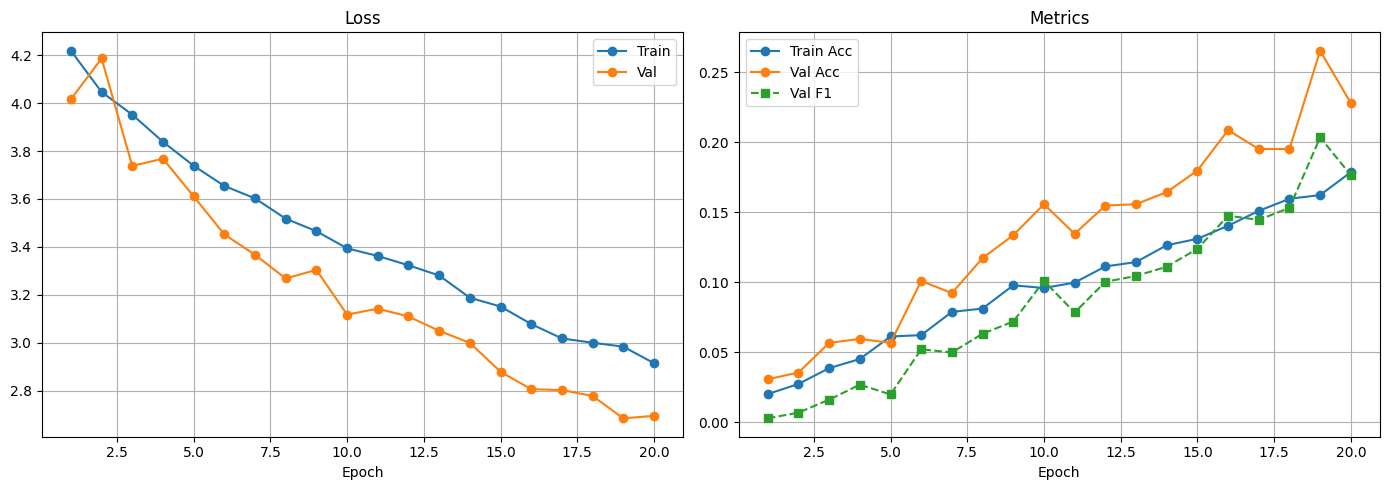

In [6]:
e = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(e, history['train_loss'], label='Train', marker='o')
axes[0].plot(e, history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(e, history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(e, history['val_acc'],   label='Val Acc',   marker='o')
axes[1].plot(e, history['val_f1'],    label='Val F1',    marker='s', linestyle='--')
axes[1].set_title('Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

os.makedirs('../outputs', exist_ok=True)
plt.tight_layout()
plt.savefig('../outputs/baseline_learning_curves.png', dpi=150)
plt.show()

## 7. Per-class Validation Analysis

In [7]:
# Reload best model and evaluate on validation set
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

preds_all, labels_all = [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Val Evaluation'):
        preds_all.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
        labels_all.extend(labels.numpy())

val_acc_final = accuracy_score(labels_all, preds_all)
val_f1_final  = f1_score(labels_all, preds_all, average='weighted')

print('=' * 50)
print('BASELINE CNN - BEST MODEL - VALIDATION RESULTS')
print('=' * 50)
print(f'Val Accuracy : {val_acc_final:.4f}')
print(f'Val F1-Score : {val_f1_final:.4f}  (weighted)')
print('=' * 50)

# Save for comparison with augmented models
with open('../outputs/baseline_results.json', 'w') as f:
    json.dump({'model': 'Baseline CNN', 'val_accuracy': val_acc_final,
               'val_f1_weighted': val_f1_final}, f, indent=2)
print('Saved to ../outputs/baseline_results.json')

report_df = pd.DataFrame(classification_report(
    labels_all, preds_all, target_names=train_dataset.classes, output_dict=True
)).T.dropna()

print('\n10 hardest classes:')
display(report_df.sort_values('f1-score').head(10)[['f1-score', 'support']])

Val Evaluation:   0%|          | 0/33 [00:00<?, ?it/s]

BASELINE CNN - BEST MODEL - VALIDATION RESULTS
Val Accuracy : 0.2654
Val F1-Score : 0.2035  (weighted)
Saved to ../outputs/baseline_results.json

10 hardest classes:


/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

,f1-score,support
GOLD BANDED,0.0,12.0
GREAT JAY,0.0,15.0
GREAT EGGFLY,0.0,12.0
STRAITED QUEEN,0.0,14.0
MALACHITE,0.0,12.0
MANGROVE SKIPPER,0.0,14.0
MESTRA,0.0,14.0
WOOD SATYR,0.0,11.0
DANAID EGGFLY,0.0,15.0
CRIMSON PATCH,0.0,12.0


## 8. Generate Kaggle Submission File

Runs the best model on the unlabelled `test/` folder and saves `submission.csv` for the Kaggle leaderboard.

In [8]:
import torchvision.transforms as T
from PIL import Image

# List all test images
test_files = sorted(os.listdir(test_dir))
print(f'Test images: {len(test_files)}')

# Same transform as validation (no augmentation)
_, val_transform = get_transforms()

model.eval()
predictions = []

with torch.no_grad():
    for fname in tqdm(test_files, desc='Predicting test set'):
        img_path = os.path.join(test_dir, fname)
        img = Image.open(img_path).convert('RGB')
        img_tensor = val_transform(img).unsqueeze(0).to(device)
        pred_idx = model(img_tensor).argmax(1).item()
        pred_label = idx_to_class[pred_idx]
        predictions.append({'filename': fname, 'label': pred_label})

submission_df = pd.DataFrame(predictions)
submission_df.to_csv('../outputs/baseline_submission.csv', index=False)
print('Submission saved to ../outputs/baseline_submission.csv')
display(submission_df.head())

Test images: 1300


Predicting test set:   0%|          | 0/1300 [00:00<?, ?it/s]

Submission saved to ../outputs/baseline_submission.csv


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,LARGE MARBLE
2,Image_10.jpg,CAIRNS BIRDWING
3,Image_100.jpg,POPINJAY
4,Image_1000.jpg,YELLOW SWALLOW TAIL
